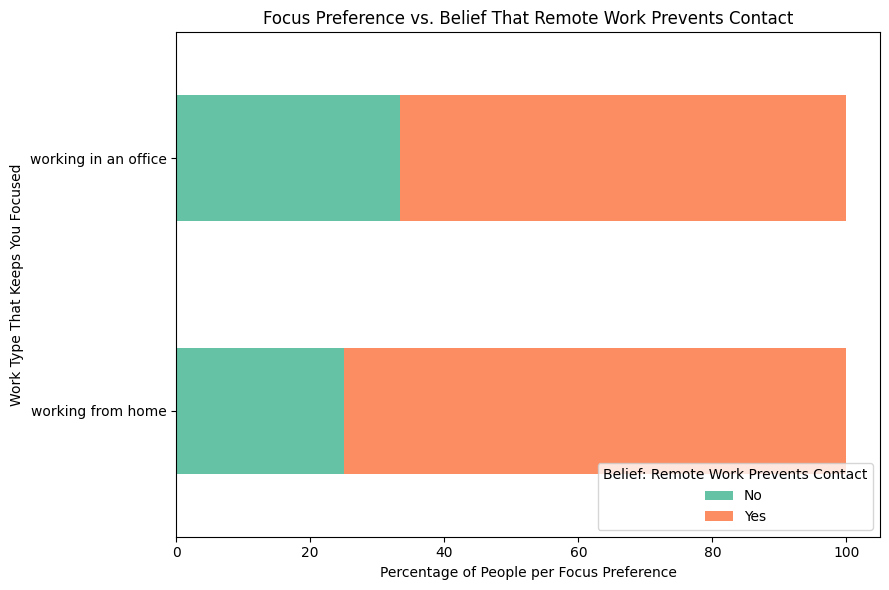

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

df = pd.read_csv('The Impacts of Working Remotely and in an Office Survey.csv')

# Clean and standardize the two relevant columns
df['focus'] = df['Which work type keeps you focused while working?'].str.strip().str.lower()
df['prevents_contact'] = df['Do you think that working from home prevents you from getting in contact with people?'].str.strip().str.lower()

# Filter out rows with missing data in either column
df_clean = df.dropna(subset=['focus', 'prevents_contact'])

df_clean['focus'] = df_clean['focus'].replace({
    'remote work': 'Remote Work Focus',
    'office work': 'Office Work Focus',
    'hybrid work': 'Hybrid Work Focus'
})

crosstab = pd.crosstab(df_clean['focus'], df_clean['prevents_contact'], normalize='index') * 100

crosstab.plot(kind='barh', stacked=True, figsize=(9,6), color=['#66c2a5','#fc8d62'])
plt.title('Focus Preference vs. Belief That Remote Work Prevents Contact')
plt.xlabel('Percentage of People per Focus Preference')
plt.ylabel('Work Type That Keeps You Focused')
plt.legend(title='Belief: Remote Work Prevents Contact', labels=['No', 'Yes'], loc='lower right')
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Impact_of_Remote_Work_on_Mental_Health.csv')
print(df['Mental_Health_Condition'].value_counts(dropna=False))



Mental_Health_Condition
Burnout       1280
Anxiety       1278
Depression    1246
NaN           1196
Name: count, dtype: int64


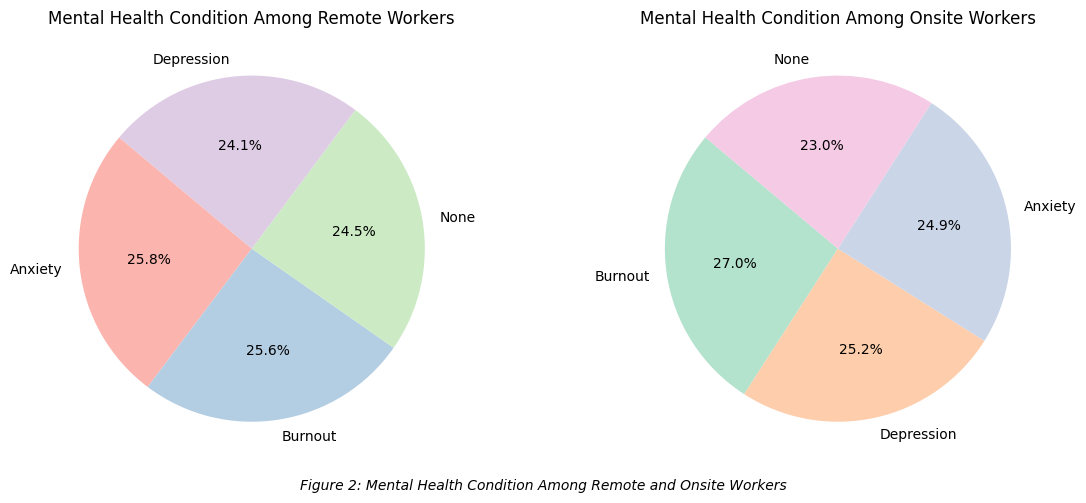

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Impact_of_Remote_Work_on_Mental_Health.csv')

# Optional: clean column names and values
df.columns = df.columns.str.strip()
df['Work_Location'] = df['Work_Location'].str.strip().str.capitalize()  # Normalize casing

# Replace NaN in Mental_Health_Condition with 'None'
df['Mental_Health_Condition'] = df['Mental_Health_Condition'].fillna('None')

# Create subsets
remote = df[df['Work_Location'] == 'Remote']
onsite = df[df['Work_Location'] == 'Onsite']  # Updated from 'Office' to 'Onsite'

# Count mental health condition distribution for each group, now including 'None'
remote_mh = remote['Mental_Health_Condition'].value_counts()
onsite_mh = onsite['Mental_Health_Condition'].value_counts()

# Plot pie charts
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pie(remote_mh, labels=remote_mh.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
plt.title('Mental Health Condition Among Remote Workers')

plt.subplot(1, 2, 2)
plt.pie(onsite_mh, labels=onsite_mh.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel2.colors)
plt.title('Mental Health Condition Among Onsite Workers')

plt.figtext(0.5, 0.01, "Figure 2: Mental Health Condition Among Remote and Onsite Workers", ha='center', fontsize=10, style='italic')
plt.tight_layout(rect=[0, 0.03, 1, 1])  # Leave space at the bottom for the caption
plt.show()




This shows that people who work remote have slightly less mental conditions

In [10]:
# Define the desired order
desired_order = ['High', 'Medium', 'Low']

# Reindex the crosstab to that order (it will put NaN if some level missing)
stress_dist = stress_dist.reindex(desired_order)

# Now plot as before
stress_dist.plot(kind='bar', figsize=(8,6), color=['#66c2a5', '#fc8d62'])
plt.title('Stress Level Distribution: Remote vs Onsite Workers')
plt.ylabel('Percentage of Workers')
plt.xlabel('Stress Level')
plt.xticks(rotation=0)
plt.legend(title='Work Location', loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


NameError: name 'stress_dist' is not defined

This shows that workers who work remote have slightly higher stress levels than the workers onsite


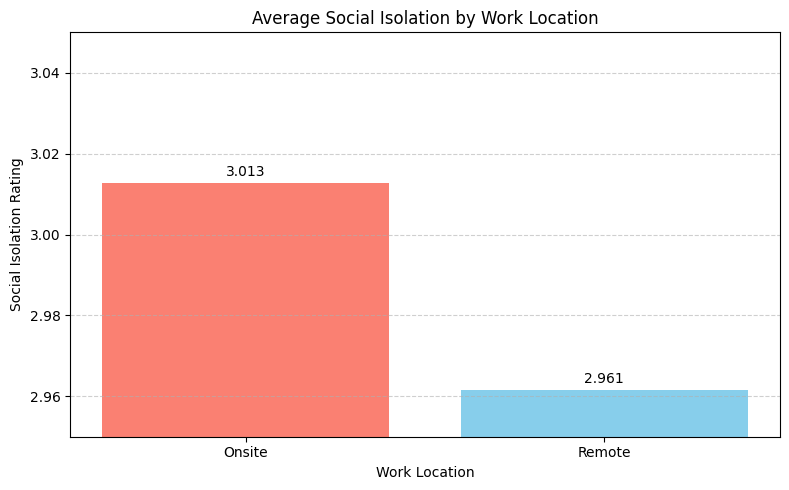

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('Impact_of_Remote_Work_on_Mental_Health.csv')

# Filter only 'Remote' and 'Onsite' workers
filtered_df = df[df['Work_Location'].isin(['Remote', 'Onsite'])].copy()

# Convert Social_Isolation_Rating to numeric safely
filtered_df.loc[:, 'Social_Isolation_Rating'] = pd.to_numeric(
    filtered_df['Social_Isolation_Rating'], errors='coerce'
)

# Group by Work_Location and compute average
avg_isolation = filtered_df.groupby('Work_Location')['Social_Isolation_Rating'].mean()

# Plotting
plt.figure(figsize=(8, 5))
bars = plt.bar(avg_isolation.index, avg_isolation.values, color=['salmon', 'skyblue'])

# Zoomed y-axis to highlight small difference
plt.ylim(2.95, 3.05)

# Title and labels
plt.title('Average Social Isolation by Work Location')
plt.ylabel('Social Isolation Rating')
plt.xlabel('Work Location')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.001, f'{height:.3f}', 
             ha='center', va='bottom', fontsize=10)



plt.tight_layout()
plt.show()


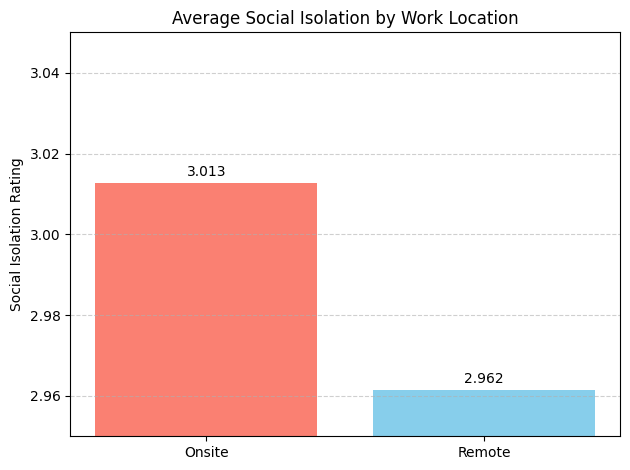

In [36]:
import matplotlib.pyplot as plt

avg_isolation = {
    'Onsite': 3.0128,
    'Remote': 2.9615
}

plt.bar(avg_isolation.keys(), avg_isolation.values(), color=['salmon', 'skyblue'])
plt.title('Average Social Isolation by Work Location')
plt.ylabel('Social Isolation Rating')

# Zoom in on y-axis to highlight the small difference
plt.ylim(2.95, 3.05)  # Focusing on the narrow range

# Add exact values on top of bars
for i, (label, value) in enumerate(avg_isolation.items()):
    plt.text(i, value + 0.001, f"{value:.3f}", ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Impact_of_Remote_Work_on_Mental_Health.csv')

# Filter for Remote and Onsite only
filtered_df = df[df['Work_Location'].isin(['Remote', 'Onsite'])].copy()

# Calculate counts for each category in Productivity_Change by Work_Location
counts = filtered_df.groupby(['Work_Location', 'Productivity_Change']).size().unstack(fill_value=0)

# Convert counts to percentages
percentages = counts.divide(counts.sum(axis=1), axis=0) * 100

print(percentages)


Productivity_Change   Decrease   Increase  No Change
Work_Location                                       
Onsite               34.086744  31.398900  34.514356
Remote               34.305718  32.555426  33.138856
